In [ ]:
# Install required library for interactive sliders
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.9 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display

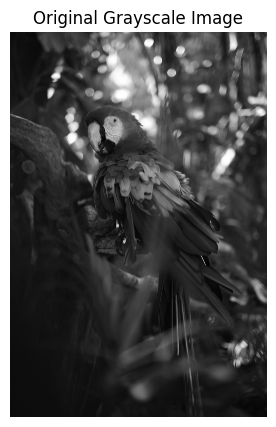

Image Shape: (7728, 5152)


In [ ]:
# Read image (change path if needed)
img = cv2.imread('/content/Lab3.jpg')

# Convert from BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Display grayscale image
plt.figure(figsize=(6,5))
plt.imshow(img_gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

# Print shape
print("Image Shape:", img_gray.shape)

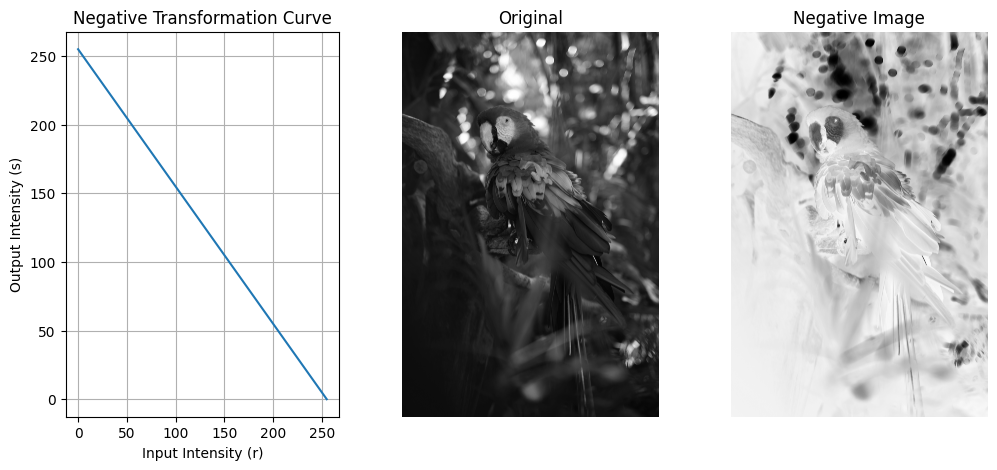

In [ ]:
# Create intensity values (0-255)
r = np.arange(256)

# Apply negative transformation formula
s = 255 - r

# Apply transformation on image
negative = 255 - img_gray

# Plot curve + comparison
plt.figure(figsize=(12,5))

# Plot transformation curve
plt.subplot(1,3,1)
plt.plot(r, s)
plt.title("Negative Transformation Curve")
plt.xlabel("Input Intensity (r)")
plt.ylabel("Output Intensity (s)")
plt.grid()

# Original Image
plt.subplot(1,3,2)
plt.imshow(img_gray, cmap='gray')
plt.title("Original")
plt.axis('off')

# Negative Image
plt.subplot(1,3,3)
plt.imshow(negative, cmap='gray')
plt.title("Negative Image")
plt.axis('off')

plt.show()

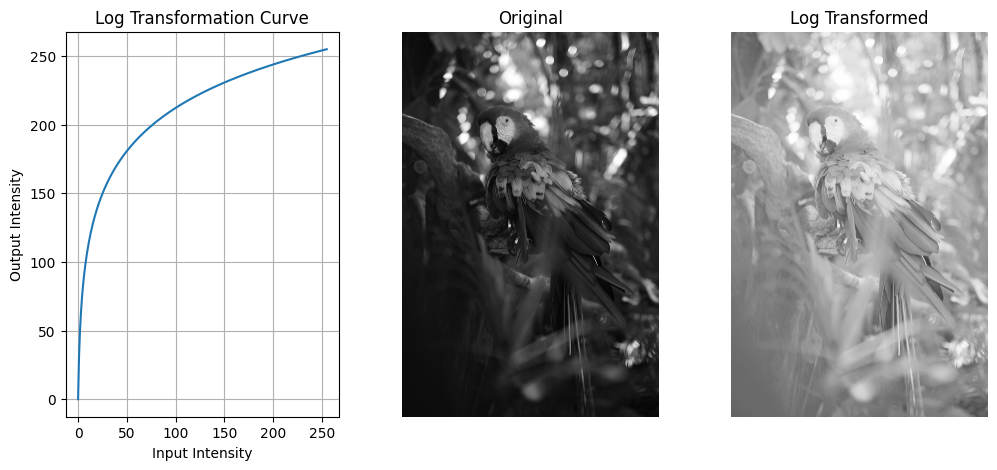

In [ ]:
# Convert image to float
img_float = img_gray.astype(np.float32)

# Create input intensity values
r = np.linspace(0, 255, 256)

# Compute scaling constant
c = 255 / np.log(1 + 255)

# Log curve
s = c * np.log(1 + r)

# Apply log transformation to image
log_transformed = c * np.log(1 + img_float)
log_transformed = np.uint8(log_transformed)

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.plot(r, s)
plt.title("Log Transformation Curve")
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.grid()

plt.subplot(1,3,2)
plt.imshow(img_gray, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(log_transformed, cmap='gray')
plt.title("Log Transformed")
plt.axis('off')

plt.show()

In [ ]:
def gamma_transform(gamma):

    # Normalize image
    normalized = img_gray / 255.0

    # Apply gamma correction
    gamma_img = np.power(normalized, gamma)

    # Scale back
    gamma_img = np.uint8(gamma_img * 255)

    # Curve plotting
    r = np.linspace(0, 1, 256)
    s = np.power(r, gamma)

    plt.figure(figsize=(12,5))

    # Curve
    plt.subplot(1,3,1)
    plt.plot(r, s)
    plt.title(f"Gamma Curve (γ={gamma})")
    plt.xlabel("Input Intensity (Normalized)")
    plt.ylabel("Output Intensity")
    plt.grid()

    # Original
    plt.subplot(1,3,2)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Gamma Output
    plt.subplot(1,3,3)
    plt.imshow(gamma_img, cmap='gray')
    plt.title(f"Gamma={gamma}")
    plt.axis('off')

    plt.show()

    # Histogram
    plt.figure(figsize=(6,4))
    plt.hist(gamma_img.ravel(), bins=256)
    plt.title(f"Histogram After Gamma Transformation (γ={gamma})")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()


# Create slider
gamma_slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=3.0,
    step=0.1,
    description='Gamma:'
)

widgets.interact(gamma_transform, gamma=gamma_slider)

interactive(children=(FloatSlider(value=1.0, description='Gamma:', max=3.0, min=0.1), Output()), _dom_classes=…

<function __main__.gamma_transform(gamma)>

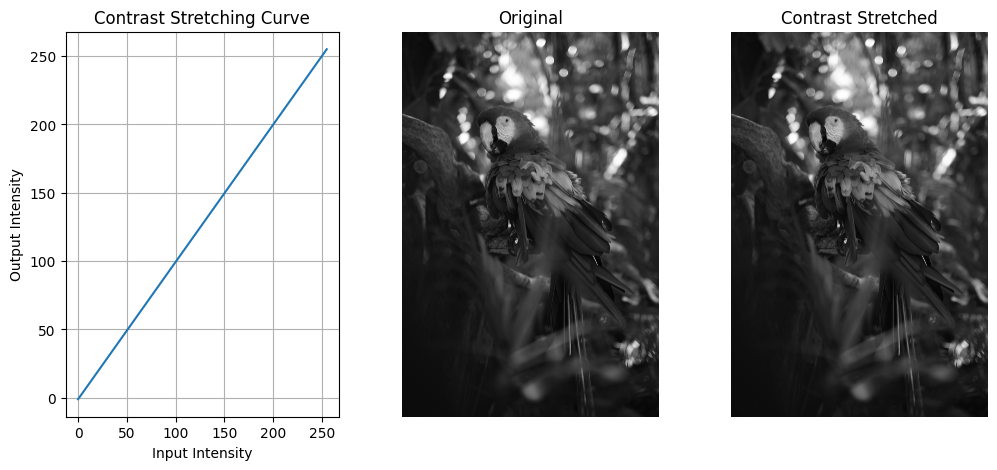

In [ ]:
# Get min and max intensity
r_min = np.min(img_gray)
r_max = np.max(img_gray)

# Apply contrast stretching
contrast_img = (img_gray - r_min) * (255 / (r_max - r_min))
contrast_img = np.uint8(contrast_img)

# Curve
r = np.linspace(0, 255, 256)
s = (r - r_min) * (255 / (r_max - r_min))

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.plot(r, s)
plt.title("Contrast Stretching Curve")
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.grid()

plt.subplot(1,3,2)
plt.imshow(img_gray, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(contrast_img, cmap='gray')
plt.title("Contrast Stretched")
plt.axis('off')

plt.show()

In [ ]:
def threshold_transform(thresh):

    # Apply threshold
    _, thresh_img = cv2.threshold(img_gray, thresh, 255, cv2.THRESH_BINARY)

    # Curve
    r = np.arange(256)
    s = np.where(r > thresh, 255, 0)

    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.plot(r, s)
    plt.title(f"Threshold Curve (T={thresh})")
    plt.xlabel("Input Intensity")
    plt.ylabel("Output Intensity")
    plt.grid()

    plt.subplot(1,3,2)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(thresh_img, cmap='gray')
    plt.title(f"Threshold={thresh}")
    plt.axis('off')

    plt.show()


threshold_slider = widgets.IntSlider(
    value=127,
    min=0,
    max=255,
    step=1,
    description='Threshold:'
)

widgets.interact(threshold_transform, thresh=threshold_slider)

interactive(children=(IntSlider(value=127, description='Threshold:', max=255), Output()), _dom_classes=('widge…

<function __main__.threshold_transform(thresh)>

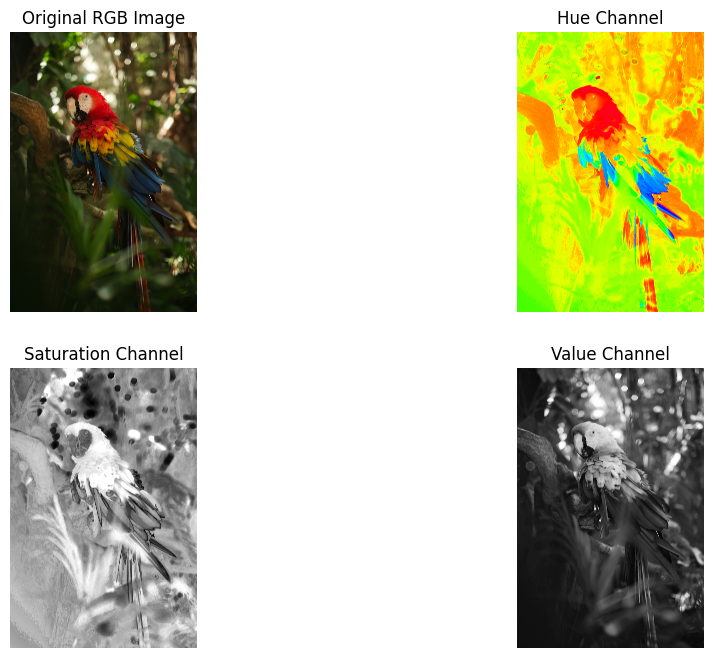

In [ ]:
img = cv2.imread('/content/Lab3.jpg')

if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Convert RGB to HSV
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Split channels
    H, S, V = cv2.split(img_hsv)

    # Plot results
    plt.figure(figsize=(12,8))

    plt.subplot(2,2,1)
    plt.imshow(img_rgb)
    plt.title("Original RGB Image")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(H, cmap='hsv')
    plt.title("Hue Channel")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(S, cmap='gray')
    plt.title("Saturation Channel")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(V, cmap='gray')
    plt.title("Value Channel")
    plt.axis("off")

    plt.show()
else:
    print("Error: Image not loaded.")

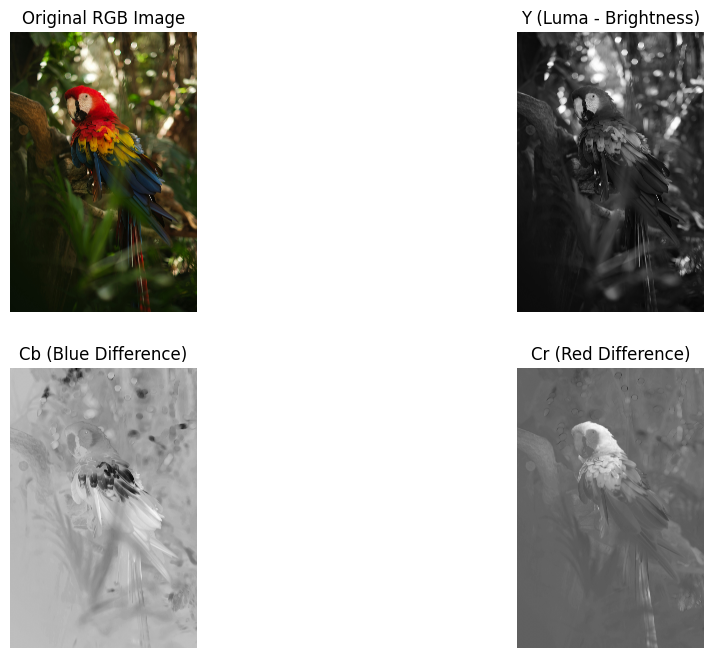

In [ ]:
img = cv2.imread('/content/Lab3.jpg')

if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Convert RGB to YCbCr
    img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

    # Split channels
    Y, Cr, Cb = cv2.split(img_ycrcb)

    # Plot results
    plt.figure(figsize=(12,8))

    plt.subplot(2,2,1)
    plt.imshow(img_rgb)
    plt.title("Original RGB Image")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(Y, cmap='gray')
    plt.title("Y (Luma - Brightness)")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(Cb, cmap='gray')
    plt.title("Cb (Blue Difference)")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(Cr, cmap='gray')
    plt.title("Cr (Red Difference)")
    plt.axis("off")

    plt.show()
else:
    print("Error: Image not loaded.")